In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

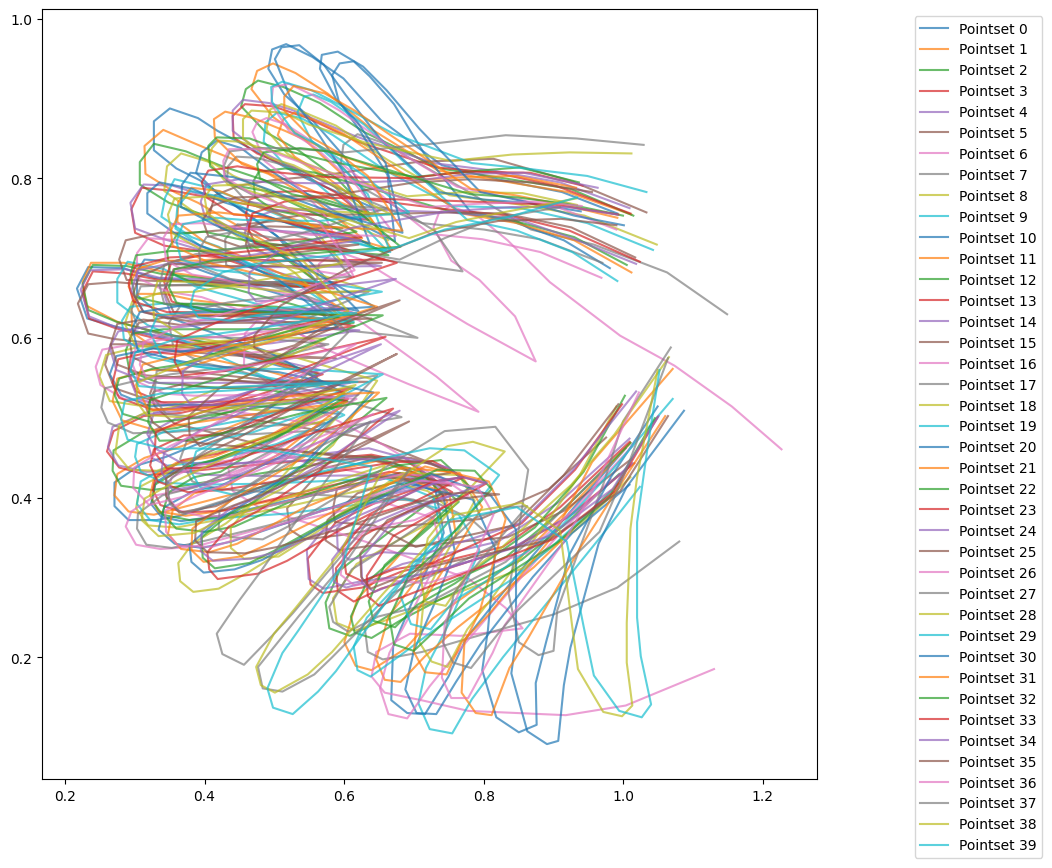

In [5]:
file = h5py.File('data/hands2D.mat', 'r')

data = np.array(file['shapes'])

plt.figure(figsize=(10, 10))
for i in range(data.shape[0]):
    points = data[i]
    plt.plot(points[:, 0], points[:, 1], label=f'Pointset {i}', alpha=0.7)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

In [6]:
# assumes shape1 and shape2 are in pre shape space (centroid 0 and norm 1)
def code1(shape1, shape2):

    cross_covariance = np.dot(shape2.T, shape1)
    
    # singular value decomposition
    U, _, Vt = np.linalg.svd(cross_covariance)
    
    # get determinant to check if valid rotation matrix
    det = np.linalg.det(U) * np.linalg.det(Vt)
    
    # if det < 0, reflection occurs, need to adjust to get only rotation
    if det < 0:
        U_adjusted = U.copy()
        # negate the last column
        U_adjusted[:, -1] = -U[:, -1]
        
        # calculate the adjusted rotation matrix
        R = np.dot(Vt.T, U_adjusted.T)
    else:
        # otherwise, no need of adjustment
        R = np.dot(Vt.T, U.T)
    
    # rotate shape 2 to align with shape 1
    aligned_shape2 = np.dot(shape2, R.T)
    
    # return the norm 
    distance = np.linalg.norm(shape1 - aligned_shape2)
    
    return distance, R

In [7]:
# doesn't assume shape 1 and shape 2 are in pre shape space
# shifts, scales and rotates shape 2 to best fit shape 1
def code2(shape1, shape2):

    n = shape1.shape[0]
    
    x1 = shape1[:, 0]  
    y1 = shape1[:, 1]  
    x2 = shape2[:, 0]  
    y2 = shape2[:, 1]  
    
    # solve: Ac = b where c = [tx, ty, a, b]^T
    
    A = np.zeros((4, 4))
    A[0, 0] = n
    A[0, 2] = -np.sum(x2)
    A[0, 3] = np.sum(y2)
    
    A[1, 1] = n
    A[1, 2] = -np.sum(y2)
    A[1, 3] = -np.sum(x2)
    
    A[2, 0] = np.sum(x2)
    A[2, 1] = np.sum(y2)
    A[2, 2] = -np.sum(x2*x2 + y2*y2)
    
    A[3, 0] = -np.sum(y2)
    A[3, 1] = np.sum(x2)
    A[3, 3] = -np.sum(x2*x2 + y2*y2)
    
    b = np.zeros(4)
    b[0] = np.sum(x1)
    b[1] = np.sum(y1)
    b[2] = np.sum(x1*x2 + y1*y2)
    b[3] = np.sum(y1*x2 - x1*y2)
    
    # solve the linear system
    c = np.linalg.solve(A, b)
    
    # get parameters from solution
    tx, ty, a, b = c

    a = -a
    b = -b
    
    # get scale and rotation from the solution
    s = np.sqrt(a*a + b*b)
    theta = np.arctan2(b, a)
    
    # construct the rotation matrix from theta
    R = np.array([[np.cos(theta), -np.sin(theta)], 
                  [np.sin(theta), np.cos(theta)]])
    
    # translation vector
    T = np.array([tx, ty])
    
    # transform shape 2 using the solution
    M = np.array([[a, -b], [b, a]]) 
    shape2_transformed = np.dot(shape2, M.T) + T
    
    # get the distance
    distance = np.linalg.norm(shape1 - shape2_transformed)
    
    return distance, T, s, R

0.0669361169291004
0.06631260524626875
[[ 1.00000000e+00 -5.61334798e-17]
 [ 2.21422276e-16  1.00000000e+00]]
[[ 1.00000000e+00 -1.98999517e-18]
 [ 1.98999517e-18  1.00000000e+00]]
1.011892790064528


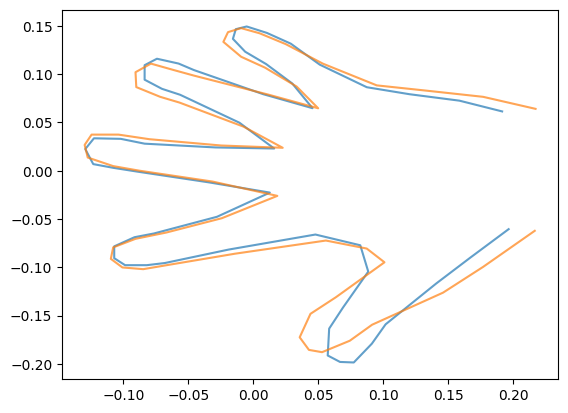

In [17]:
points = data[0]
plt.plot(points[:, 0], points[:, 1], label='Pointset 1', alpha=0.7)

points = data[1]
plt.plot(points[:, 0], points[:, 1], label='Pointset 2', alpha=0.7)

z1 = data[0] - np.mean(data[0], axis=1, keepdims=True)
z1 = z1 / np.sqrt(np.sum(data[0]*data[0]))

z2 = data[1] - np.mean(data[1], axis=1, keepdims=True)
z2 = z2 / np.sqrt(np.sum(data[1]*data[1]))

d1, R1 = code1(z1, z2)
d2, _, s, R2 = code2(z1, z2)

print(d1)
print(d2)

print(R1)
print(R2)
print(s)

In [9]:
def code11(pointsets, max_iterations=10000, tolerance=1e-4):

    # pre-processing
    for i in range(len(pointsets)):
        centroid = np.mean(pointsets[i], axis=0)

        # ensure centroid is origin
        pointsets[i] = pointsets[i] - centroid
        
        # ensure norm is 1
        norm = np.sqrt(np.sum(pointsets[i]**2))
        pointsets[i] = pointsets[i] / norm

    # initialize the mean shape as the 0th shape
    mean_shape = pointsets[0].copy()
    
    for iteration in tqdm(range(max_iterations)):

        aligned_pointsets = []
        for pointset in pointsets:
            # get optimal rotation from code1
            _, R = code1(mean_shape, pointset)
            
            # apply rotation to the pointset to align it
            aligned_pointset = np.dot(pointset,     R.T)
            aligned_pointsets.append(aligned_pointset)
        
        # compute the mean shape 
        new_mean = np.mean(aligned_pointsets, axis=0)
        
        # normalize the mean to have norm 1, no need to take care of centroid 0 (ensured by all elements having centroid 0)
        norm = np.sqrt(np.sum(new_mean**2))
        new_mean /= norm
        
        # early termination check
        if np.linalg.norm(new_mean - mean_shape) < tolerance:
            break
        
        # update the mean shape
        mean_shape = new_mean
    
    return mean_shape, aligned_pointsets

  0%|          | 2/10000 [00:00<00:17, 575.39it/s]


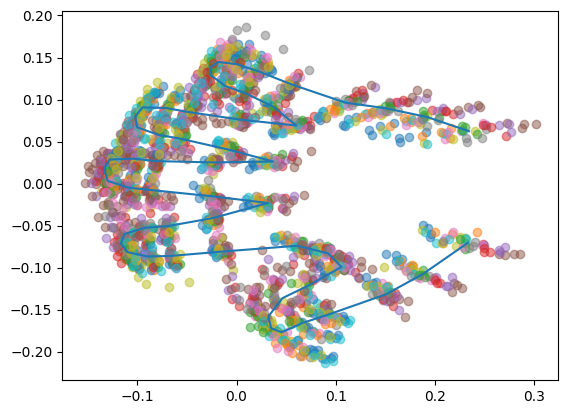

In [10]:
mean_shape_1, aligned_pointsets_1 = code11(data)

points = mean_shape_1
plt.plot(points[:, 0], points[:, 1], label=f'Mean Shape', alpha=1)

for i, pointset in enumerate(aligned_pointsets_1):
    plt.scatter(pointset[:, 0], pointset[:, 1], label=f'{i}', alpha=0.5)

In [11]:
def code22(pointsets, max_iterations=10000, tolerance=1e-4):
    
    # initialize mean shape to the first pointset
    mean_shape = pointsets[0].copy()
    
    # center the initial mean
    centroid = np.mean(mean_shape, axis=0)
    mean_shape -= centroid
    
    for iteration in tqdm(range(max_iterations)):

        # align shapes to current mean
        aligned_pointsets = []
        for pointset in pointsets:
            
            # get optimal scale, translation and rotation to apply to pointset to align best with mean shape
            _, T, s, R = code2(mean_shape, pointset)
            
            # apply the transformation to get the aligned pointset
            aligned_pointset = s * np.dot(pointset, R.T) + T
            aligned_pointsets.append(aligned_pointset)
        
        # compute the new mean shape
        new_mean = np.mean(aligned_pointsets, axis=0)
        
        # early termination check
        if np.linalg.norm(new_mean - mean_shape) < tolerance:
            break
        
        # update the mean shape
        mean_shape = new_mean
    
    return mean_shape, aligned_pointsets

  2%|▏         | 239/10000 [00:00<00:15, 624.84it/s]


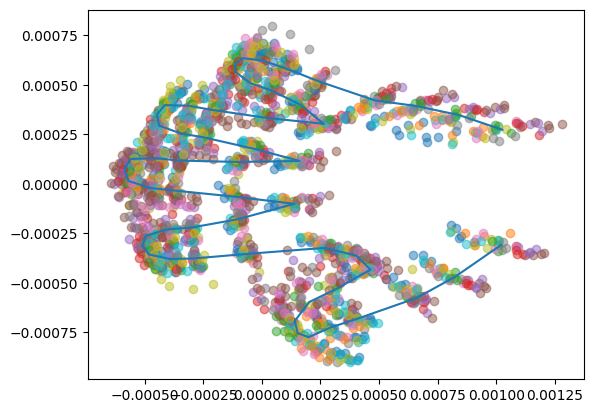

In [12]:
mean_shape_2, aligned_pointsets_2 = code22(data)

points = mean_shape_2
plt.plot(points[:, 0], points[:, 1], label=f'Mean Shape', alpha=1)

for i, pointset in enumerate(aligned_pointsets_2):
    plt.scatter(pointset[:, 0], pointset[:, 1], label=f'{i}', alpha=0.5)

In [13]:
# variation using code 1
mean_shape_code11, aligned_pointsets_code11 = code11(data)

shape_vectors_code11 = np.array([shape.flatten() for shape in aligned_pointsets_code11])

cov_matrix_code11 = np.cov(shape_vectors_code11, rowvar=False)

# eigen decomposition
eigenvalues_code11, eigenvectors_code11 = np.linalg.eigh(cov_matrix_code11)

# sorting by descending eigenvalues
index_code11 = np.argsort(eigenvalues_code11)[::-1]
eigenvalues_code11 = eigenvalues_code11[index_code11]
eigenvectors_code11 = eigenvectors_code11[:, index_code11]

# variation using code 2
mean_shape_code22, aligned_pointsets_code22 = code22(data)

shape_vectors_code22 = np.array([shape.flatten() for shape in aligned_pointsets_code22])

cov_matrix_code22 = np.cov(shape_vectors_code22, rowvar=False)

# eigen decomposition
eigenvalues_code22, eigenvectors_code22 = np.linalg.eigh(cov_matrix_code22)

index_code22 = np.argsort(eigenvalues_code22)[::-1]
eigenvalues_code22 = eigenvalues_code22[index_code22]
eigenvectors_code22 = eigenvectors_code22[:, index_code22]

  2%|▏         | 239/10000 [00:00<00:19, 502.06it/s]


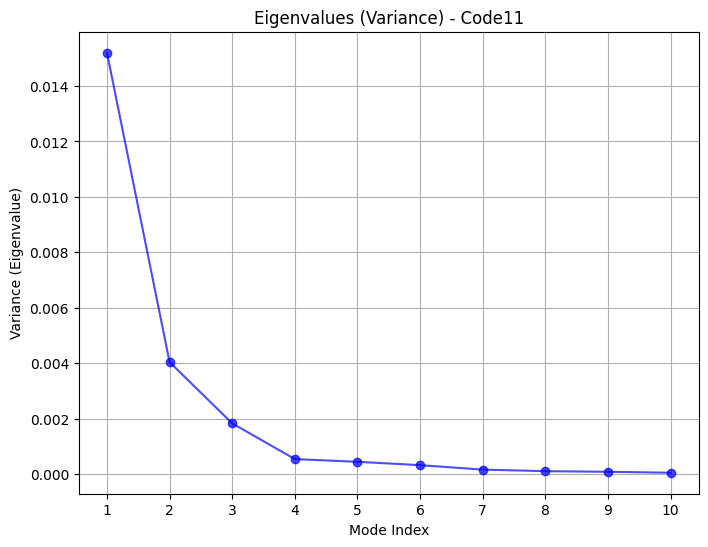

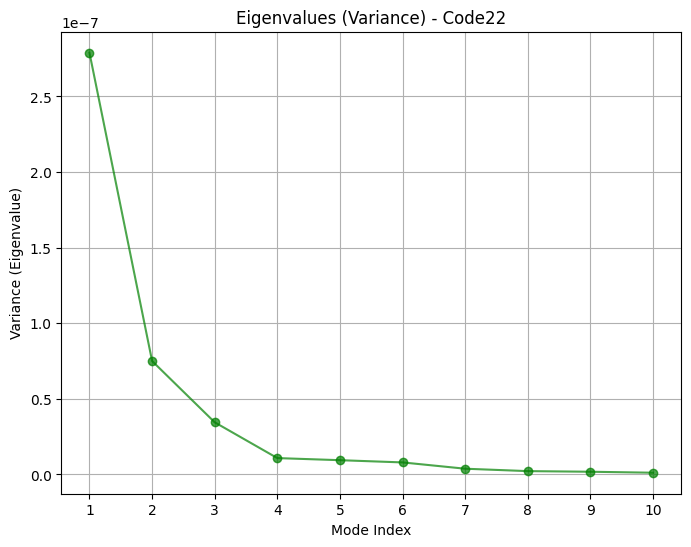

In [14]:
n = 10

# Plot eigenvalues for Code11
plt.figure(figsize=(8, 6))
plt.plot(range(1, n + 1), eigenvalues_code11[:n], marker='o', color='blue', alpha=0.7)
plt.title('Eigenvalues (Variance) - Code11')
plt.xlabel('Mode Index')
plt.ylabel('Variance (Eigenvalue)')
plt.xticks(range(1, n + 1))
plt.grid(True)
plt.show()

# Plot eigenvalues for Code22
plt.figure(figsize=(8, 6))
plt.plot(range(1, n + 1), eigenvalues_code22[:n], marker='o', color='green', alpha=0.7)
plt.title('Eigenvalues (Variance) - Code22')
plt.xlabel('Mode Index')
plt.ylabel('Variance (Eigenvalue)')
plt.xticks(range(1, n + 1))
plt.grid(True)
plt.show()

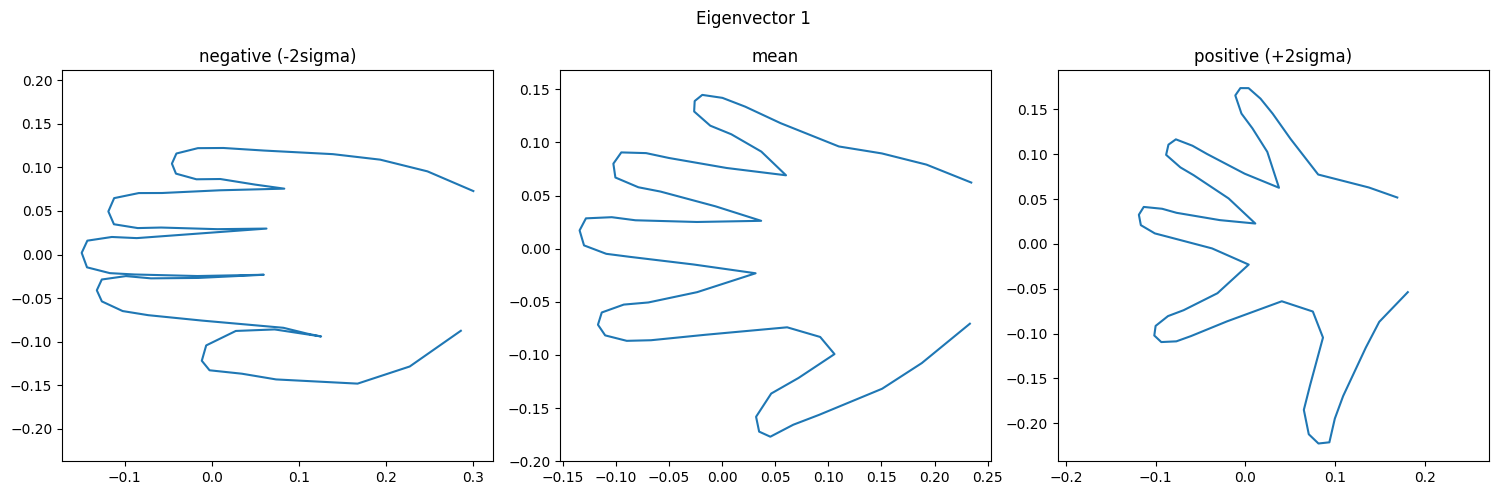

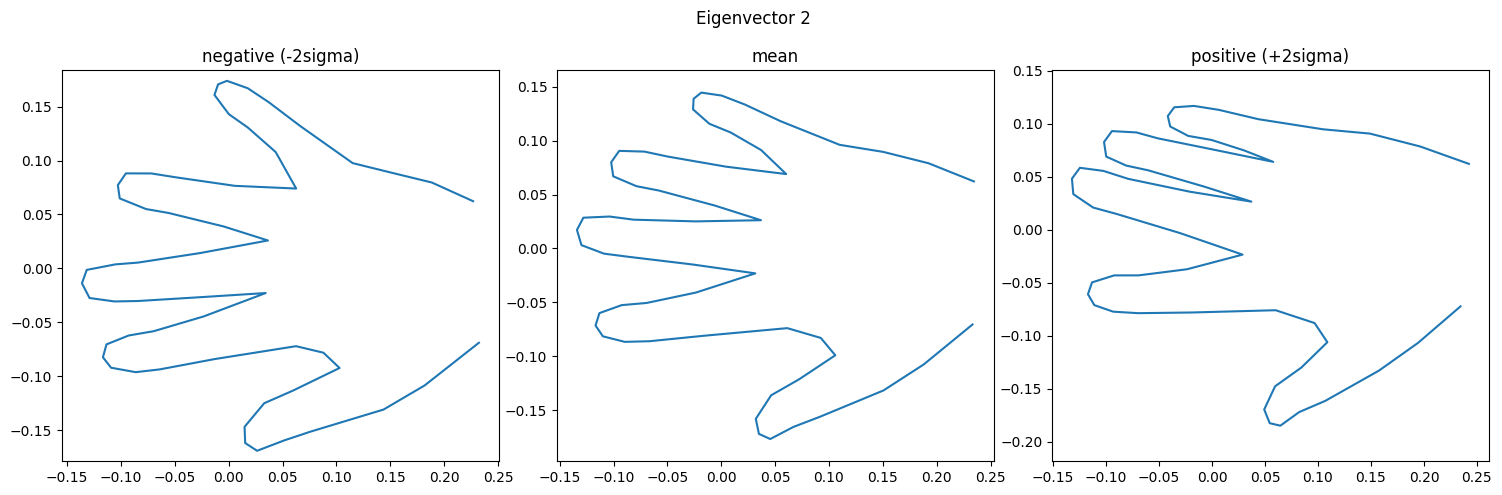

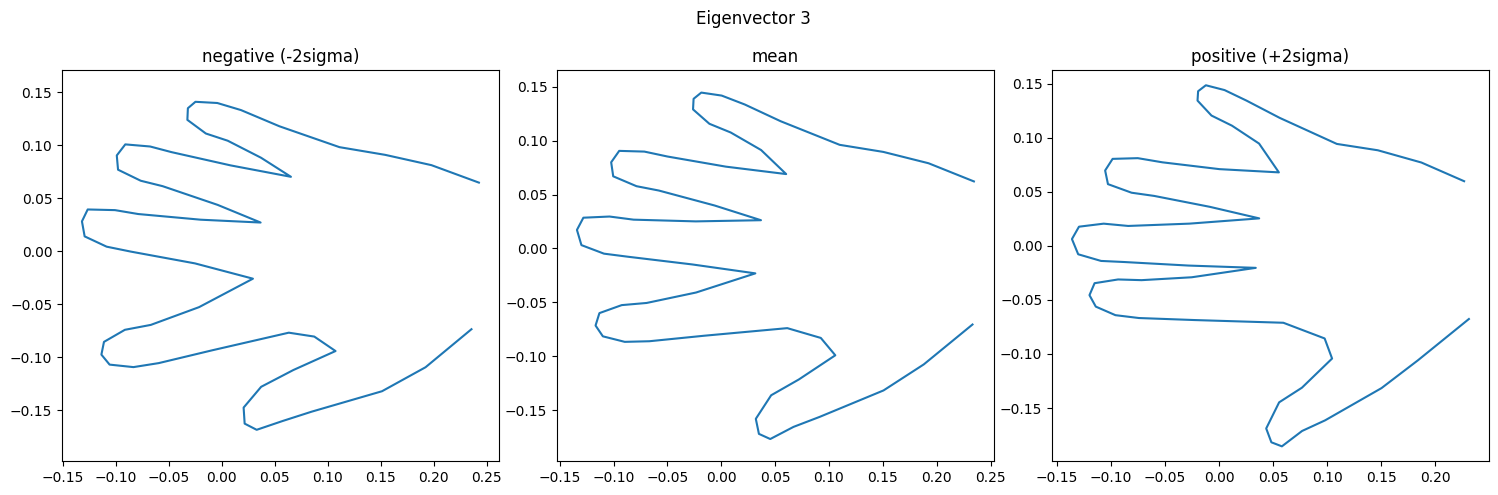

In [15]:
for i in range(3):
    plt.figure(figsize=(15, 5))
    
    # get the eigen value and corresponding eigen vector
    eigen_value = eigenvalues_code11[i]
    eigen_vector = eigenvectors_code11[:, i].reshape(-1, 2)
    
    # compute and plot negative variation
    neg_variation = mean_shape_code11 - 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 1)
    plt.plot(neg_variation[:, 0], neg_variation[:, 1])
    plt.title('negative (-2sigma)')
    plt.axis('equal')
    
    # plot the mean shape
    plt.subplot(1, 3, 2)
    plt.plot(mean_shape_code11[:, 0], mean_shape_code11[:, 1])
    plt.title('mean')
    plt.axis('equal')
    
    # compute and plot positive variation
    pos_variation = mean_shape_code11 + 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 3)
    plt.plot(pos_variation[:, 0], pos_variation[:, 1])
    plt.title('positive (+2sigma)')
    plt.axis('equal')
    
    plt.suptitle(f'Eigenvector {i+1}')
    plt.tight_layout()
    plt.show()


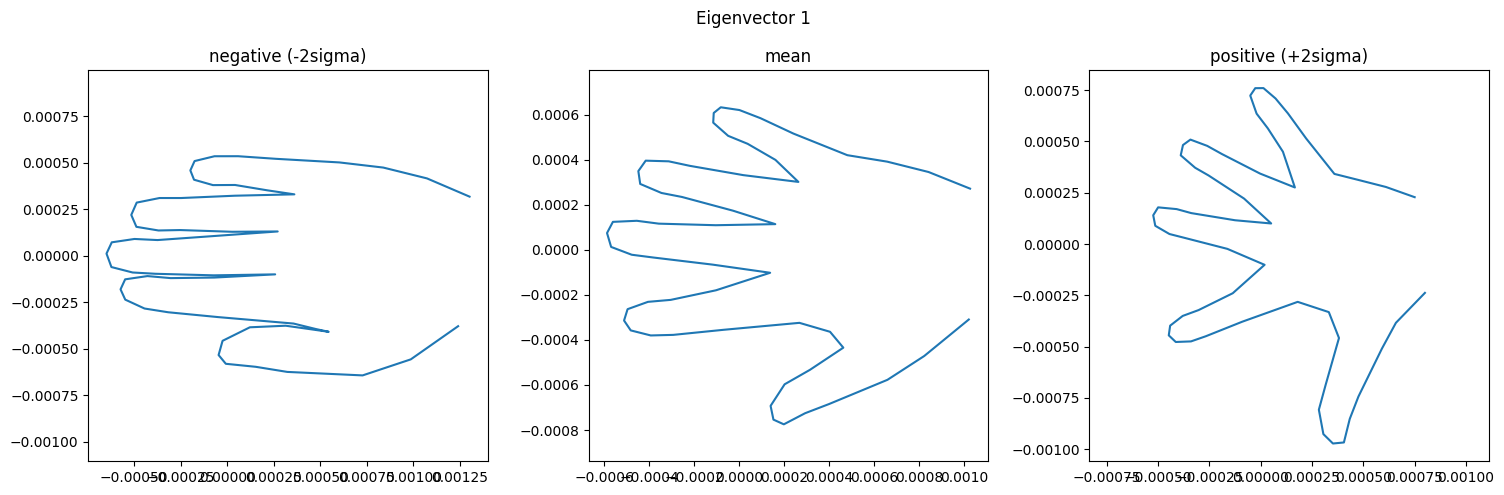

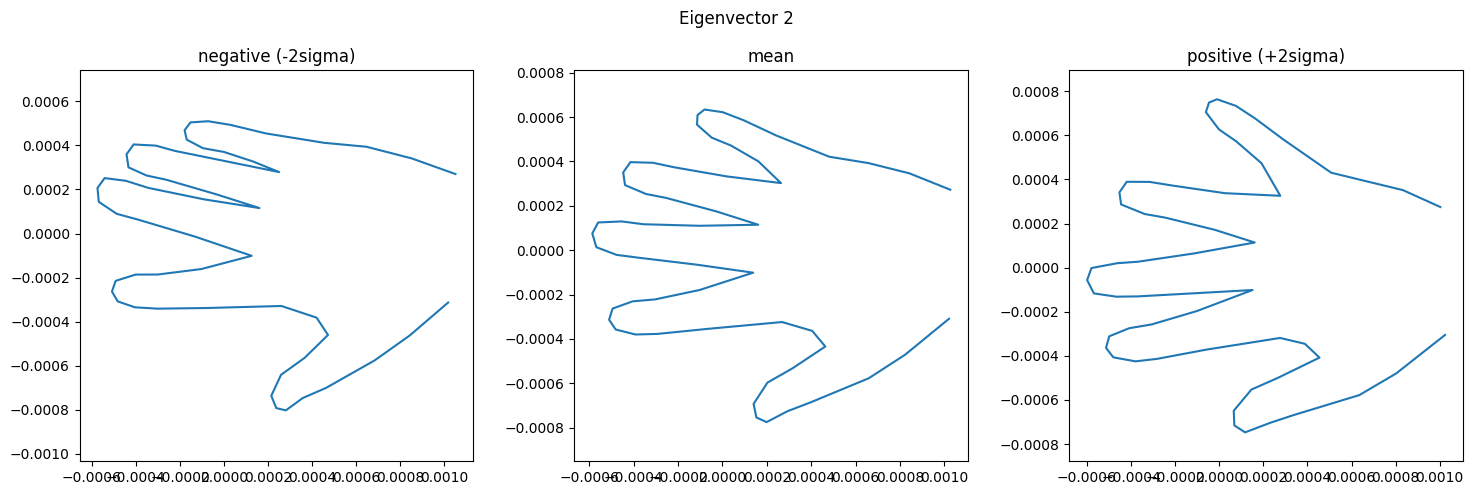

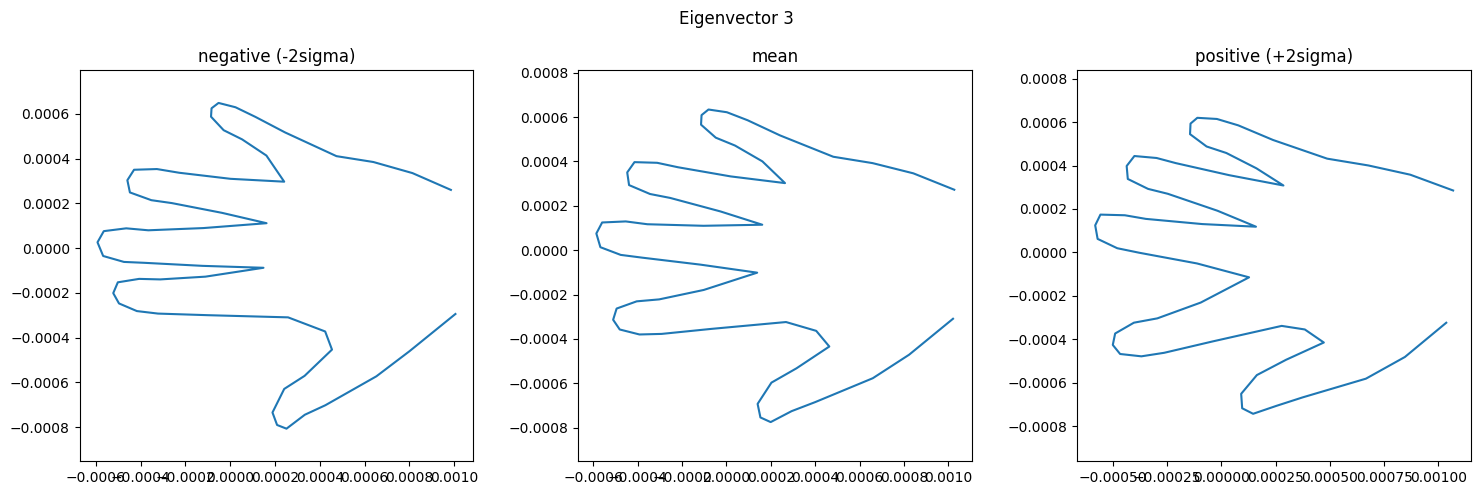

In [16]:
for i in range(3):
    plt.figure(figsize=(15, 5))
    
    # get the eigen value and corresponding eigen vector
    eigen_value = eigenvalues_code22[i]
    eigen_vector = eigenvectors_code22[:, i].reshape(-1, 2)
    
    # compute and plot negative variation
    neg_variation = mean_shape_code22 - 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 1)
    plt.plot(neg_variation[:, 0], neg_variation[:, 1])
    plt.title('negative (-2sigma)')
    plt.axis('equal')
    
    # plot the mean shape
    plt.subplot(1, 3, 2)
    plt.plot(mean_shape_code22[:, 0], mean_shape_code22[:, 1])
    plt.title('mean')
    plt.axis('equal')
    
    # compute and plot positive variation
    pos_variation = mean_shape_code22 + 2 * np.sqrt(eigen_value) * eigen_vector
    plt.subplot(1, 3, 3)
    plt.plot(pos_variation[:, 0], pos_variation[:, 1])
    plt.title('positive (+2sigma)')
    plt.axis('equal')
    
    plt.suptitle(f'Eigenvector {i+1}')
    plt.tight_layout()
    plt.show()